# Trabajo Práctico Nº 4
## Álgebra de Cuaterniones, SLERP y Velocidad Angular




# Ejercicio 2 – Clase Quaternion

Se implementa desde cero una clase `Quaternion` con:

1. Constructor con normalización automática.
2. `from_axis_angle`.
3. `from_euler_zyz`.
4. Sobrecarga de `__mul__` para el producto de Hamilton.
5. `rotate_vector` mediante el operador sándwich:
   \[
   \tilde p' = q \otimes \tilde p \otimes q^*
   \]
6. `to_rotation_matrix`.
7. `to_ros_msg`


In [5]:
import numpy as np
import math

np.set_printoptions(precision=10, suppress=True)


class Quaternion:
    "Cuaternión unitario con convención interna [w, x, y, z]."

    def __init__(self, w, x, y, z):
        q = np.array([w, x, y, z], dtype=float)
        norm = np.linalg.norm(q)

        if norm < 1e-15:
            raise ValueError("Un cuaternión de norma cero no representa una orientación.")

        # Normalización automática
        q = q / norm

        self.w, self.x, self.y, self.z = q

    @property
    def vector(self):
        return np.array([self.x, self.y, self.z])

    def as_array(self):
        return np.array([self.w, self.x, self.y, self.z])

    @classmethod
    def from_axis_angle(cls, axis, angle):
        "Construye un cuaternión desde un eje y un ángulo en radianes."
        axis = np.asarray(axis, dtype=float)
        norm = np.linalg.norm(axis)

        if norm < 1e-15:
            raise ValueError("El eje no puede tener norma cero.")

        axis = axis / norm
        half = angle / 2.0

        return cls(
            np.cos(half),
            *(axis * np.sin(half))
        )

    @classmethod
    def from_euler_zyz(cls, phi, theta, psi):
        "Construye q para la convención ZYZ."

        "q = qz(phi) ⊗ qy(theta) ⊗ qz(psi)"
        q_phi = cls.from_axis_angle([0, 0, 1], phi)
        q_theta = cls.from_axis_angle([0, 1, 0], theta)
        q_psi = cls.from_axis_angle([0, 0, 1], psi)

        return q_phi * q_theta * q_psi

    def conjugate(self):
        return Quaternion(self.w, -self.x, -self.y, -self.z)

    def __mul__(self, other):
        "Producto de Hamilton."
        if not isinstance(other, Quaternion):
            return NotImplemented

        w1, x1, y1, z1 = self.as_array()
        w2, x2, y2, z2 = other.as_array()

        return Quaternion(
            w1*w2 - x1*x2 - y1*y2 - z1*z2,
            w1*x2 + x1*w2 + y1*z2 - z1*y2,
            w1*y2 - x1*z2 + y1*w2 + z1*x2,
            w1*z2 + x1*y2 - y1*x2 + z1*w2
        )

    def rotate_vector(self, p):
        "Rota un vector mediante q ⊗ [0,p] ⊗ q*."
        p = np.asarray(p, dtype=float)

        if p.shape != (3,):
            p = p.reshape(3)

        p_quat = Quaternion(0.0, *p)
        result = self * p_quat * self.conjugate()

        return result.vector

    def to_rotation_matrix(self):
        "Convierte el cuaternión unitario a una matriz SO(3)."
        w, x, y, z = self.as_array()

        return np.array([
            [1 - 2*(y*y + z*z), 2*(x*y - z*w),     2*(x*z + y*w)],
            [2*(x*y + z*w),     1 - 2*(x*x + z*z), 2*(y*z - x*w)],
            [2*(x*z - y*w),     2*(y*z + x*w),     1 - 2*(x*x + y*y)]
        ])

    def to_ros_msg(self):
        "Devuelve el mensaje ROS Quaternion en orden x,y,z,w."
        "Si geometry_msgs no está instalado, devuelve un diccionario"
        "equivalente para poder ejecutar el notebook fuera de ROS."
        try:
            from geometry_msgs.msg import Quaternion as ROSQuaternion
            msg = ROSQuaternion()
            msg.x = float(self.x)
            msg.y = float(self.y)
            msg.z = float(self.z)
            msg.w = float(self.w)
            return msg
        except ImportError:
            return {
                "x": float(self.x),
                "y": float(self.y),
                "z": float(self.z),
                "w": float(self.w)
            }

    def __repr__(self):
        return (
            f"Quaternion(w={self.w:.6f}, x={self.x:.6f}, "
            f"y={self.y:.6f}, z={self.z:.6f})"
        )


## Prueba de la clase



In [6]:
q_test = Quaternion(2, 0, 0, 0)

print("Cuaternión normalizado:")
print(q_test)
print("Norma:", np.linalg.norm(q_test.as_array()))

q_z90 = Quaternion.from_axis_angle([0, 0, 1], np.deg2rad(90))
p = np.array([1.0, 0.0, 0.0])

p_rot = q_z90.rotate_vector(p)

print("\nRotación de [1,0,0] en 90° alrededor de Z:")
print(p_rot)

print("\nMatriz de rotación:")
print(q_z90.to_rotation_matrix())

print("\nRepresentación ROS (x,y,z,w):")
print(q_z90.to_ros_msg())


Cuaternión normalizado:
Quaternion(w=1.000000, x=0.000000, y=0.000000, z=0.000000)
Norma: 1.0

Rotación de [1,0,0] en 90° alrededor de Z:
[0. 1. 0.]

Matriz de rotación:
[[ 0. -1.  0.]
 [ 1.  0.  0.]
 [ 0.  0.  1.]]

Representación ROS (x,y,z,w):
{'x': 0.0, 'y': 0.0, 'z': 0.7071067811865475, 'w': 0.7071067811865476}


# Ejercicio 3 – SLERP y camino más corto

SLERP (Spherical Linear Interpolation) interpola sobre la esfera de cuaterniones unitarios.




In [7]:
def slerp(q0, q1, t, threshold=0.9995):
    "SLERP con corrección antipodal y límite LERP."

    q0 = q0.as_array().astype(float)
    q1 = q1.as_array().astype(float)

    q0 /= np.linalg.norm(q0)
    q1 /= np.linalg.norm(q1)

    dot = np.dot(q0, q1)

    # Camino más corto
    if dot < 0.0:
        q1 = -q1
        dot = -dot

    dot = np.clip(dot, -1.0, 1.0)

    # Límite LERP
    if dot > threshold:
        q = (1.0 - t)*q0 + t*q1
        q /= np.linalg.norm(q)
        return Quaternion(*q)

    omega = np.arccos(dot)
    sin_omega = np.sin(omega)

    a = np.sin((1.0 - t)*omega) / sin_omega
    b = np.sin(t*omega) / sin_omega

    q = a*q0 + b*q1
    q /= np.linalg.norm(q)

    return Quaternion(*q)


## Poses ZYZ del ABB IRB 120


Se generan `N = 100` pasos.


In [8]:
N = 100

phi0, theta0, psi0 = np.deg2rad([0, 30, 0])
phi1, theta1, psi1 = np.deg2rad([90, 60, 45])

q0 = Quaternion.from_euler_zyz(phi0, theta0, psi0)
q1 = Quaternion.from_euler_zyz(phi1, theta1, psi1)

dot_original = np.dot(q0.as_array(), q1.as_array())

print("q0 =", q0)
print("q1 =", q1)
print(f"Producto punto inicial q0·q1 = {dot_original:.10f}")

if dot_original < 0:
    print("Se requiere corrección antipodal.")
else:
    print("No se requiere corrección antipodal.")

t_values = np.linspace(0.0, 1.0, N)
q_path = np.array([
    slerp(q0, q1, t).as_array()
    for t in t_values
])

print("\nNúmero de cuaterniones generados:", len(q_path))
print("Norma mínima:", np.min(np.linalg.norm(q_path, axis=1)))
print("Norma máxima:", np.max(np.linalg.norm(q_path, axis=1)))


q0 = Quaternion(w=0.965926, x=0.000000, y=0.258819, z=0.000000)
q1 = Quaternion(w=0.331414, x=-0.191342, y=0.461940, z=0.800103)
Producto punto inicial q0·q1 = 0.4396797395
No se requiere corrección antipodal.

Número de cuaterniones generados: 100
Norma mínima: 0.9999999999999998
Norma máxima: 1.0


# Ejercicio 4 – Validación cinemática

Para una matriz antisimétrica:

\[
[\omega]_\times=
\begin{bmatrix}
0&-\omega_z&\omega_y\\
\omega_z&0&-\omega_x\\
-\omega_y&\omega_x&0
\end{bmatrix}
\]

por lo que:

\[
\omega=
\begin{bmatrix}
S_{32}\\
S_{13}\\
S_{21}
\end{bmatrix}
\]




In [9]:
# Matrices de rotación en cada paso
R_path = np.array([
    Quaternion(*q).to_rotation_matrix()
    for q in q_path
])

# Se toma t en segundos de 0 a 1.
# Por tanto, Delta t = 1/(N-1).
time_values = np.linspace(0.0, 1.0, N)
dt = time_values[1] - time_values[0]

omega_values = []

for k in range(N - 1):
    Rk = R_path[k]
    Rnext = R_path[k + 1]

    skew_omega = ((Rnext - Rk) / dt) @ Rk.T

    omega = np.array([
        skew_omega[2, 1],
        skew_omega[0, 2],
        skew_omega[1, 0]
    ])

    omega_values.append(omega)

omega_values = np.array(omega_values)
omega_norm = np.linalg.norm(omega_values, axis=1)

print(f"N = {N}")
print(f"Delta t = {dt:.12f} s")
print(f"||omega|| mínimo = {omega_norm.min():.12f} rad/s")
print(f"||omega|| máximo = {omega_norm.max():.12f} rad/s")
print(f"||omega|| promedio = {omega_norm.mean():.12f} rad/s")


N = 100
Delta t = 0.010101010101 s
||omega|| mínimo = 2.231625560353 rad/s
||omega|| máximo = 2.231625560353 rad/s
||omega|| promedio = 2.231625560353 rad/s


## Cálculo del error de constancia




In [10]:
omega_mean = np.mean(omega_norm)
omega_min = np.min(omega_norm)
omega_max = np.max(omega_norm)

error_percent = (omega_max - omega_min) / omega_mean * 100

print(f"Error de constancia = {error_percent:.12f} %")

if error_percent < 0.5:
    print("VALIDACIÓN EXITOSA: el error es menor que 0.5 %.")
else:
    print("VALIDACIÓN NO SUPERADA: el error es mayor o igual a 0.5 %.")

Error de constancia = 0.000000000005 %
VALIDACIÓN EXITOSA: el error es menor que 0.5 %.


## Gráfica de \(\|\omega(t_k)\|\) vs. tiempo

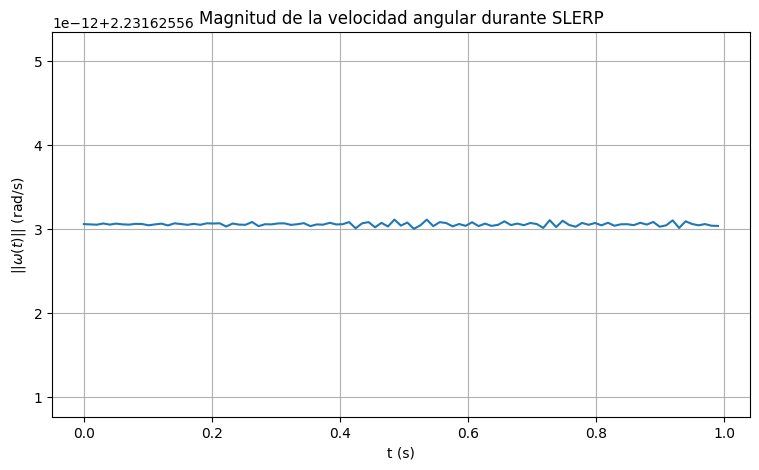

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(time_values[:-1], omega_norm)
plt.xlabel("t (s)")
plt.ylabel(r"$||\omega(t)||$ (rad/s)")
plt.title("Magnitud de la velocidad angular durante SLERP")
plt.grid(True)
plt.show()


# Verificación del camino corto




In [12]:
shortest_angle = 2 * np.arccos(
    np.clip(abs(dot_original), -1.0, 1.0)
)

print(f"Ángulo geodésico del camino corto = {np.rad2deg(shortest_angle):.6f}°")
print(f"Ángulo equivalente en radianes = {shortest_angle:.12f} rad")


Ángulo geodésico del camino corto = 127.833102°
Ángulo equivalente en radianes = 2.231108521237 rad
